# Geographic Selection — NiHSA 2026 Location Flood Risk

Exploratory plots of the NiHSA 2026 AFO at-risk locations dataset in **Borno, Adamawa, and Yobe (BAY) states**, with a focus on the 4 NHF trigger LGAs selected for 2026.

Sections:
0. **Overall targeting map** — all 2026 selected LGAs (blue = CERF riverine, orange = NHF flash flood)
1. BAY states overview — all at-risk locations by depth zone
2. LGA-level summary — location counts and at-risk population
3. Selected LGA detail — 4 NHF trigger LGAs with location overlay
4. Depth profile — flood depth distribution for selected LGAs

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ocha_stratus as stratus
from dotenv import load_dotenv
from matplotlib.lines import Line2D

load_dotenv()

True

In [3]:
# Admin boundaries
gdf_lga  = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_adm1 = stratus.codab.load_codab_from_blob("NGA", admin_level=1)

BAY_STATES = ["Borno", "Adamawa", "Yobe"]
gdf_bay      = gdf_lga[gdf_lga["ADM1_EN"].isin(BAY_STATES)].copy()
gdf_bay_adm1 = gdf_adm1[gdf_adm1["ADM1_EN"].isin(BAY_STATES)].copy()
xmin, ymin, xmax, ymax = gdf_bay.total_bounds

# ── 2026 selected LGAs ────────────────────────────────────────────────────────
# CERF riverine trigger — Adamawa (Benue river system, same as 2025)
RIVERINE_PCODES = [
    "NG002002",  # Fufore
    "NG002021",  # Yola South
    "NG002020",  # Yola North
    "NG002005",  # Girei
    "NG002001",  # Demsa
    "NG002016",  # Numan
    "NG002009",  # Lamurde
]

# NHF flash flood trigger — Borno and Yobe
NHF_2026 = {
    "NG008023": "Mobbar",
    "NG008021": "Maiduguri",
    "NG036006": "Geidam",
    "NG008013": "Jere",
}

gdf_riverine = gdf_lga[gdf_lga["ADM2_PCODE"].isin(RIVERINE_PCODES)].copy()
gdf_nhf      = gdf_lga[gdf_lga["ADM2_PCODE"].isin(NHF_2026.keys())].copy()

print(f"CERF riverine LGAs: {gdf_riverine['ADM2_EN'].tolist()}")
print(f"NHF flash flood LGAs: {gdf_nhf['ADM2_EN'].tolist()}")

CERF riverine LGAs: ['Demsa', 'Fufore', 'Girei', 'Lamurde', 'Numan', 'Yola North', 'Yola South']
NHF flash flood LGAs: ['Geidam', 'Jere', 'Maiduguri', 'Mobbar']


## 0. Overall LGA Targeting Map — 2026 CERF + NHF

CERF riverine LGAs: 7
NHF 2026 flash flood LGAs: 4
Overlap: none


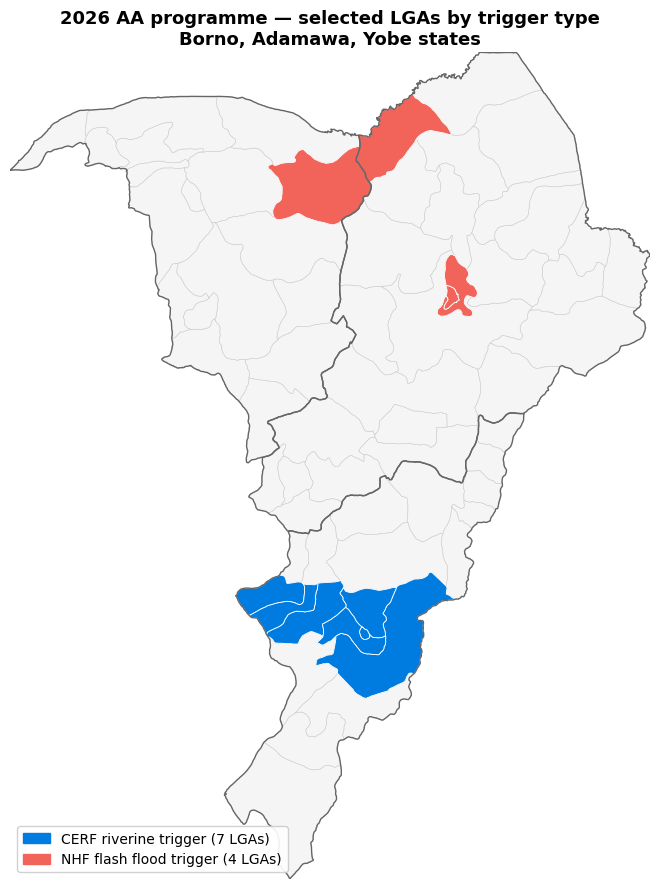

In [4]:
nhf_pcodes      = set(NHF_2026.keys())
cerf_pcodes     = set(RIVERINE_PCODES)
overlap         = nhf_pcodes & cerf_pcodes

print(f"CERF riverine LGAs: {len(cerf_pcodes)}")
print(f"NHF 2026 flash flood LGAs: {len(nhf_pcodes)}")
print(f"Overlap: {overlap if overlap else 'none'}")

def _classify(pcode):
    in_nhf  = pcode in nhf_pcodes
    in_cerf = pcode in cerf_pcodes
    if in_nhf and in_cerf:
        return "both"
    if in_nhf:
        return "nhf"
    if in_cerf:
        return "riverine"
    return None

COLOR_MAP = {
    "riverine": "#007CE0",
    "nhf":      "#F2645A",
    "both":     "#1EBFB3",
}

gdf_combined = gdf_bay.copy()
gdf_combined["_class"] = gdf_combined["ADM2_PCODE"].apply(_classify)

gdf_bg = gdf_combined[gdf_combined["_class"].isna()]
gdf_hl = gdf_combined[gdf_combined["_class"].notna()]

fig, ax = plt.subplots(figsize=(10, 9))

gdf_bg.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.4, zorder=1)
gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#666666", linewidth=1.0, zorder=4)

for cls, color in COLOR_MAP.items():
    sub = gdf_hl[gdf_hl["_class"] == cls]
    if not sub.empty:
        sub.plot(ax=ax, facecolor=color, edgecolor="white", linewidth=0.6, zorder=3)

legend_handles = [
    mpatches.Patch(color="#007CE0", label=f"CERF riverine trigger ({len(cerf_pcodes - nhf_pcodes)} LGAs)"),
    mpatches.Patch(color="#F2645A", label=f"NHF flash flood trigger ({len(nhf_pcodes - cerf_pcodes)} LGAs)"),
]
if overlap:
    legend_handles.insert(
        1,
        mpatches.Patch(color="#1EBFB3", label=f"Both triggers ({len(overlap)} LGAs)"),
    )
ax.legend(handles=legend_handles, loc="lower left", fontsize=10, framealpha=0.9)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    "2026 AA programme — selected LGAs by trigger type\nBorno, Adamawa, Yobe states",
    fontsize=13, fontweight="bold",
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

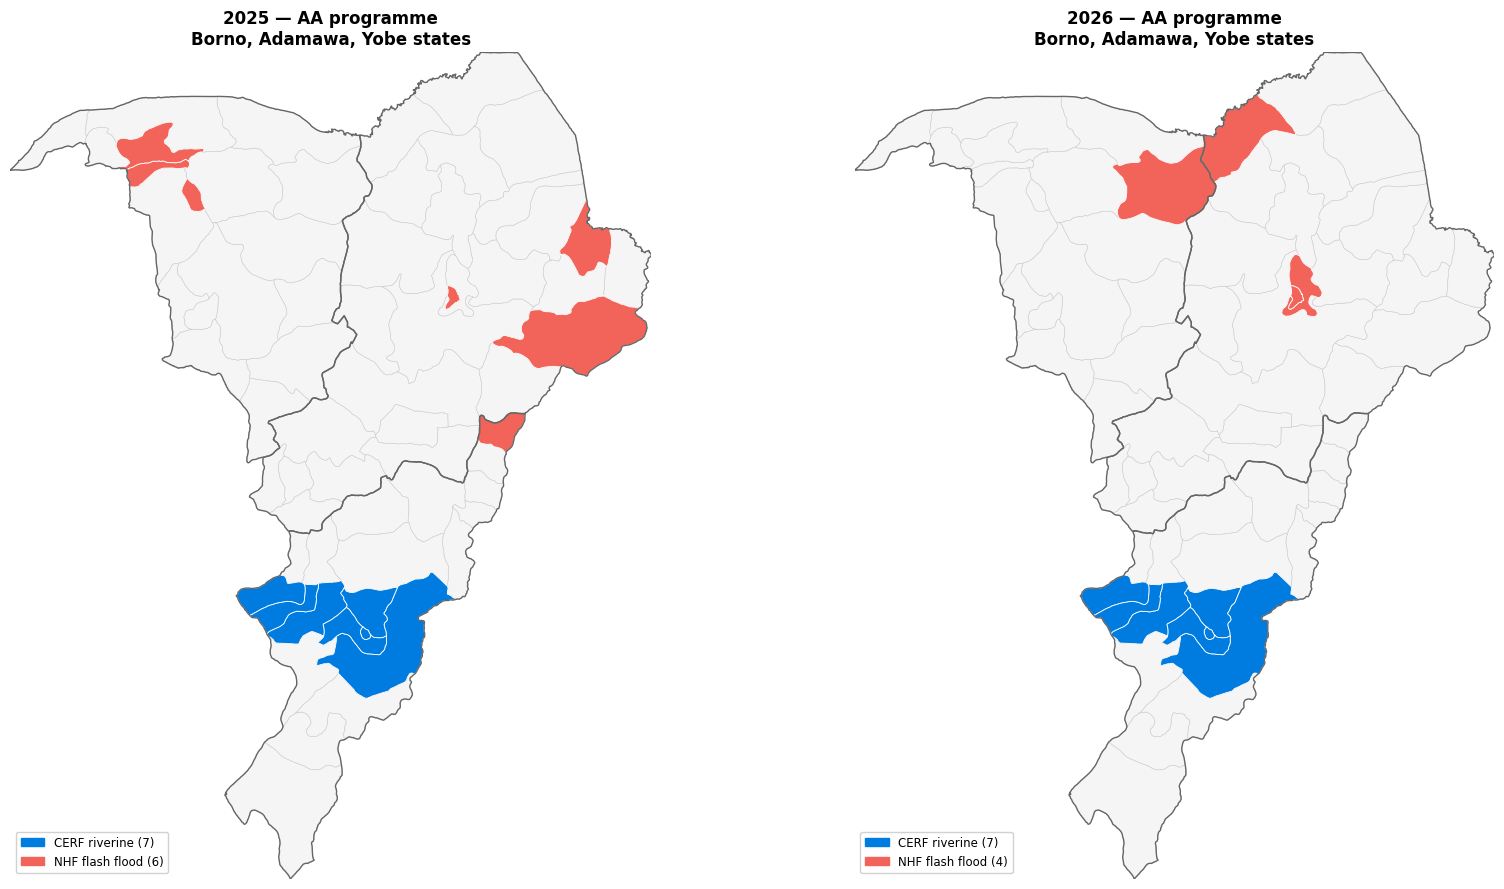

In [5]:
# 2025 NHF flash flood trigger LGAs (for comparison)
NHF_2025_PCODES = [
    "NG008003",  # Bama
    "NG036001",  # Bade
    "NG036010",  # Karasuwa
    "NG002010",  # Madagali
    "NG008021",  # Maiduguri
    "NG008025",  # Ngala
]

def _classify_year(pcode, nhf_pcodes_yr):
    in_nhf  = pcode in nhf_pcodes_yr
    in_cerf = pcode in cerf_pcodes
    if in_nhf and in_cerf:
        return "both"
    if in_nhf:
        return "nhf"
    if in_cerf:
        return "riverine"
    return None

def _draw_targeting_panel(ax, nhf_pcodes_yr, title):
    gdf_c = gdf_bay.copy()
    gdf_c["_class"] = gdf_c["ADM2_PCODE"].apply(lambda p: _classify_year(p, nhf_pcodes_yr))

    gdf_bg2 = gdf_c[gdf_c["_class"].isna()]
    gdf_hl2 = gdf_c[gdf_c["_class"].notna()]

    gdf_bg2.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.4, zorder=1)
    gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#666666", linewidth=1.0, zorder=4)

    for cls, color in COLOR_MAP.items():
        sub = gdf_hl2[gdf_hl2["_class"] == cls]
        if not sub.empty:
            sub.plot(ax=ax, facecolor=color, edgecolor="white", linewidth=0.6, zorder=3)

    ovlp = nhf_pcodes_yr & cerf_pcodes
    n_riverine = len(cerf_pcodes - nhf_pcodes_yr)
    n_nhf      = len(nhf_pcodes_yr - cerf_pcodes)
    handles = [
        mpatches.Patch(color="#007CE0", label=f"CERF riverine ({n_riverine})"),
        mpatches.Patch(color="#F2645A", label=f"NHF flash flood ({n_nhf})"),
    ]
    if ovlp:
        handles.insert(1, mpatches.Patch(color="#1EBFB3", label=f"Both ({len(ovlp)})"))
    ax.legend(handles=handles, loc="lower left", fontsize=8.5, framealpha=0.9)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()


fig, axes = plt.subplots(1, 2, figsize=(18, 9))

_draw_targeting_panel(
    axes[0],
    set(NHF_2025_PCODES),
    "2025 — AA programme\nBorno, Adamawa, Yobe states",
)
_draw_targeting_panel(
    axes[1],
    nhf_pcodes,
    "2026 — AA programme\nBorno, Adamawa, Yobe states",
)

plt.tight_layout()
plt.show()

In [6]:
# NiHSA 2026 AFO at-risk locations
df_risk = stratus.load_csv_from_blob(
    "ds-aa-nga-flooding/raw/AA-nigeria_data/NiHSA/AFO_communities_atrisk_2026.csv"
)
df_risk["depth_zone"] = df_risk["depth_zone"].str.strip().str.capitalize()

gdf_risk = gpd.GeoDataFrame(
    df_risk,
    geometry=gpd.points_from_xy(df_risk["lon"], df_risk["lat"]),
    crs="EPSG:4326",
)

# Filter to BAY states
gdf_risk_bay = gpd.sjoin(
    gdf_risk,
    gdf_bay[["ADM2_PCODE", "ADM2_EN", "ADM1_EN", "geometry"]],
    how="inner",
    predicate="within",
).drop(columns="index_right")

print(f"Total NiHSA locations (Nigeria): {len(gdf_risk):,}")
print(f"BAY states: {len(gdf_risk_bay):,}")
print()
print(gdf_risk_bay["depth_zone"].value_counts().to_string())
print()
print(f"Population at risk (BAY): {gdf_risk_bay['population'].sum():,.0f}")

Total NiHSA locations (Nigeria): 30,707
BAY states: 7,210

depth_zone
Medium    5545
High      1190
Low        475

Population at risk (BAY): 0


## 1. BAY States Overview — At-Risk Locations by Depth Zone

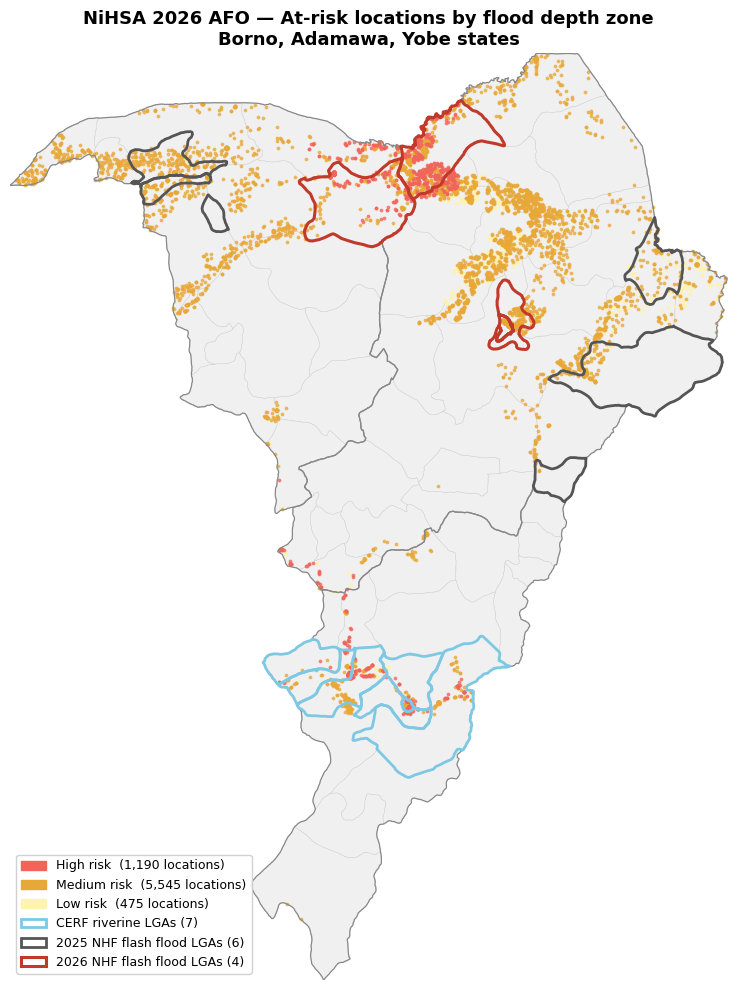

In [7]:
ZONE_COLORS = {"High": "#F2645A", "Medium": "#E8A838", "Low": "#FFF3B0"}
ZONE_ORDER  = ["High", "Medium", "Low"]

gdf_nhf_2025 = gdf_lga[gdf_lga["ADM2_PCODE"].isin(NHF_2025_PCODES)].copy()

fig, ax = plt.subplots(figsize=(11, 10))

gdf_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3, zorder=1)
gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.9, zorder=3)

for zone in reversed(ZONE_ORDER):
    sub = gdf_risk_bay[gdf_risk_bay["depth_zone"] == zone]
    if sub.empty:
        continue
    sub.plot(ax=ax, color=ZONE_COLORS[zone], markersize=3, alpha=0.7, zorder=2)

# CERF riverine — light blue outline
gdf_riverine.plot(ax=ax, facecolor="none", edgecolor="#7EC8E3", linewidth=2.0, zorder=4)

# 2025 NHF flash flood — dark grey outline
gdf_nhf_2025.plot(ax=ax, facecolor="none", edgecolor="#555555", linewidth=2.0, zorder=4)

# 2026 NHF flash flood — red outline
gdf_nhf.plot(ax=ax, facecolor="none", edgecolor="#C0392B", linewidth=2.2, zorder=5)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_axis_off()

legend_handles = [
    mpatches.Patch(color=ZONE_COLORS[z],
                   label=f"{z} risk  ({len(gdf_risk_bay[gdf_risk_bay['depth_zone']==z]):,} locations)")
    for z in ZONE_ORDER if z in gdf_risk_bay["depth_zone"].values
] + [
    mpatches.Patch(facecolor="none", edgecolor="#7EC8E3", linewidth=2.0,
                   label=f"CERF riverine LGAs ({len(gdf_riverine)})"),
    mpatches.Patch(facecolor="none", edgecolor="#555555", linewidth=2.0,
                   label=f"2025 NHF flash flood LGAs ({len(gdf_nhf_2025)})"),
    mpatches.Patch(facecolor="none", edgecolor="#C0392B", linewidth=2.2,
                   label=f"2026 NHF flash flood LGAs ({len(gdf_nhf)})"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.9)

ax.set_title(
    "NiHSA 2026 AFO — At-risk locations by flood depth zone\nBorno, Adamawa, Yobe states",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

## 1b. NiHSA Risk Locations + Trigger LGA Selection

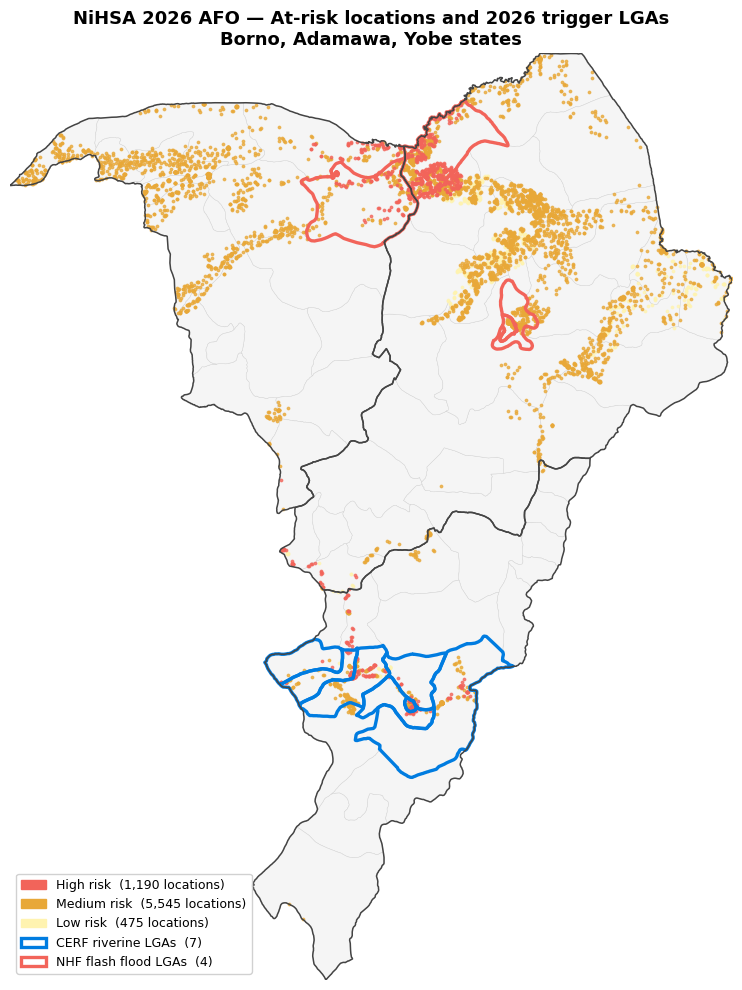

In [8]:
fig, ax = plt.subplots(figsize=(11, 10))

gdf_bay.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#d0d0d0", linewidth=0.3, zorder=1)

for zone in reversed(ZONE_ORDER):
    sub = gdf_risk_bay[gdf_risk_bay["depth_zone"] == zone]
    if sub.empty:
        continue
    sub.plot(ax=ax, color=ZONE_COLORS[zone], markersize=3, alpha=0.75, zorder=2)

gdf_riverine.plot(ax=ax, facecolor="none", edgecolor="#007CE0", linewidth=2.4, zorder=4)
gdf_nhf.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=2.4, zorder=4)
gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#444444", linewidth=1.1, zorder=5)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_axis_off()

community_handles = [
    mpatches.Patch(color=ZONE_COLORS[z],
                   label=f"{z} risk  ({len(gdf_risk_bay[gdf_risk_bay['depth_zone']==z]):,} locations)")
    for z in ZONE_ORDER if z in gdf_risk_bay["depth_zone"].values
]
trigger_handles = [
    mpatches.Patch(facecolor="none", edgecolor="#007CE0", linewidth=2.4,
                   label=f"CERF riverine LGAs  ({len(gdf_riverine)})"),
    mpatches.Patch(facecolor="none", edgecolor="#F2645A", linewidth=2.4,
                   label=f"NHF flash flood LGAs  ({len(gdf_nhf)})"),
]
ax.legend(handles=community_handles + trigger_handles,
          loc="lower left", fontsize=9, framealpha=0.9)

ax.set_title(
    "NiHSA 2026 AFO — At-risk locations and 2026 trigger LGAs\nBorno, Adamawa, Yobe states",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

## 2. LGA-Level Summary — Location Counts and At-Risk Population

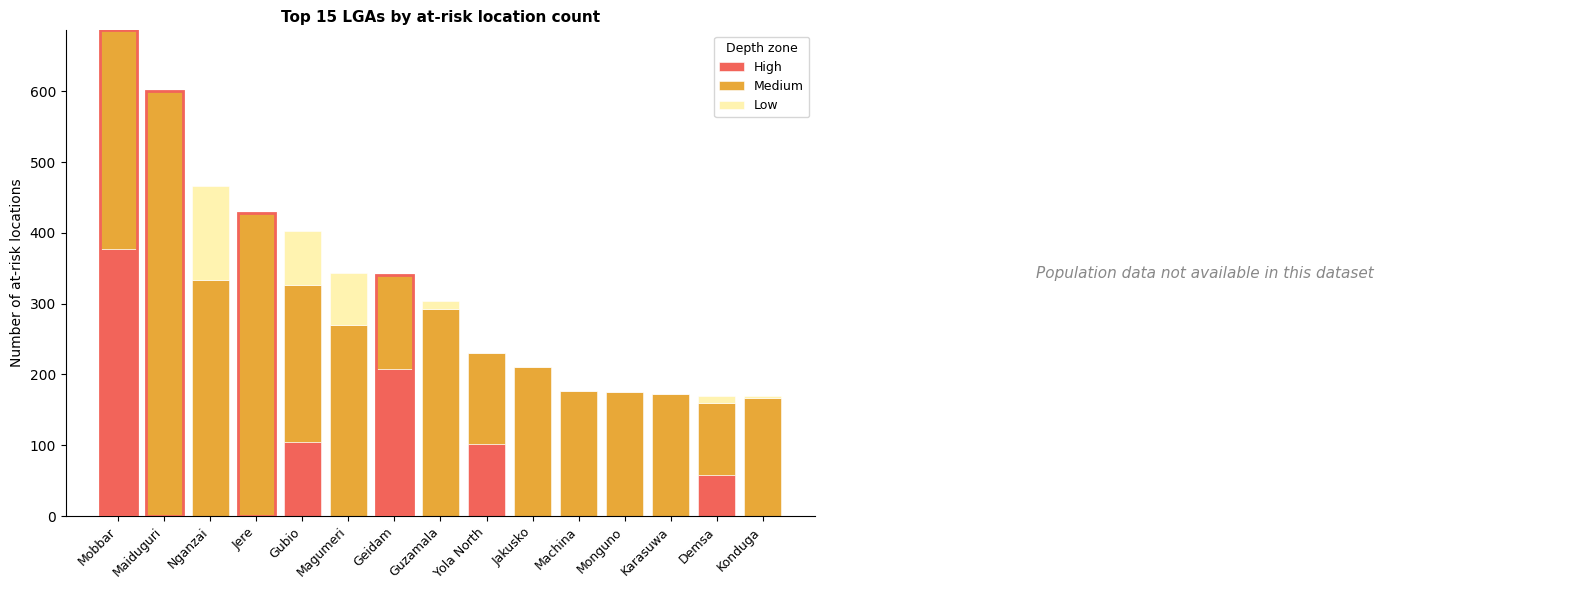

In [9]:
# Aggregate by LGA and depth zone
df_lga_summary = (
    gdf_risk_bay.groupby(["ADM2_PCODE", "ADM2_EN", "ADM1_EN", "depth_zone"])
    .agg(n_communities=("name", "count"), population=("population", "sum"))
    .reset_index()
)

df_lga_total = (
    df_lga_summary.groupby(["ADM2_PCODE", "ADM2_EN", "ADM1_EN"])
    .agg(total_communities=("n_communities", "sum"), total_pop=("population", "sum"))
    .reset_index()
    .sort_values("total_communities", ascending=False)
)

df_lga_total["is_nhf"] = df_lga_total["ADM2_PCODE"].isin(NHF_2026.keys())

TOP_N = 15
df_top = df_lga_total.head(TOP_N)

# Pivot on pcode only to avoid duplicate ADM2_EN after merge
df_wide_pivot = (
    df_lga_summary[df_lga_summary["ADM2_PCODE"].isin(df_top["ADM2_PCODE"])]
    .pivot_table(index="ADM2_PCODE", columns="depth_zone",
                 values="n_communities", fill_value=0)
    .reset_index()
)
df_wide_pivot.columns.name = None
df_wide = df_top[["ADM2_PCODE", "ADM2_EN", "is_nhf"]].merge(df_wide_pivot, on="ADM2_PCODE")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: stacked bar — location counts ───────────────────────────────────
ax = axes[0]
labels = df_wide["ADM2_EN"].tolist()
x = np.arange(len(labels))
bottom = np.zeros(len(labels))

for zone in ZONE_ORDER:
    if zone in df_wide.columns:
        vals = df_wide[zone].values
        ax.bar(x, vals, bottom=bottom, color=ZONE_COLORS[zone],
               label=zone, edgecolor="white", linewidth=0.4)
        bottom += vals

# Outline NHF LGAs
for _, row in df_wide.iterrows():
    if row["is_nhf"]:
        idx = labels.index(row["ADM2_EN"])
        ax.bar(idx, bottom[idx], color="none", edgecolor="#F2645A",
               linewidth=2.0, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Number of at-risk locations", fontsize=10)
ax.set_title(f"Top {TOP_N} LGAs by at-risk location count", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Depth zone", fontsize=9, title_fontsize=9)

# ── Panel 2: population at risk ───────────────────────────────────────────────
ax2 = axes[1]
df_pop = df_lga_total[df_lga_total["total_pop"] > 0].head(TOP_N).copy()

if len(df_pop) > 0:
    colors = ["#F2645A" if r else "#c6dbef" for r in df_pop["is_nhf"]]
    ax2.barh(df_pop["ADM2_EN"], df_pop["total_pop"], color=colors, edgecolor="white")
    ax2.set_xlabel("Total at-risk population", fontsize=10)
    ax2.set_title(f"Top {TOP_N} LGAs by at-risk population (NiHSA 2026)",
                  fontsize=11, fontweight="bold")
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.legend(
        handles=[
            mpatches.Patch(color="#F2645A", label="2026 NHF trigger LGA"),
            mpatches.Patch(color="#c6dbef", label="Other BAY LGA"),
        ],
        fontsize=9,
    )
else:
    ax2.text(0.5, 0.5, "Population data not available in this dataset",
             ha="center", va="center", transform=ax2.transAxes,
             fontsize=11, color="#888888", style="italic")
    ax2.set_axis_off()

plt.tight_layout()
plt.show()

## 3. Selected LGA Detail — NHF 2026 Trigger LGAs

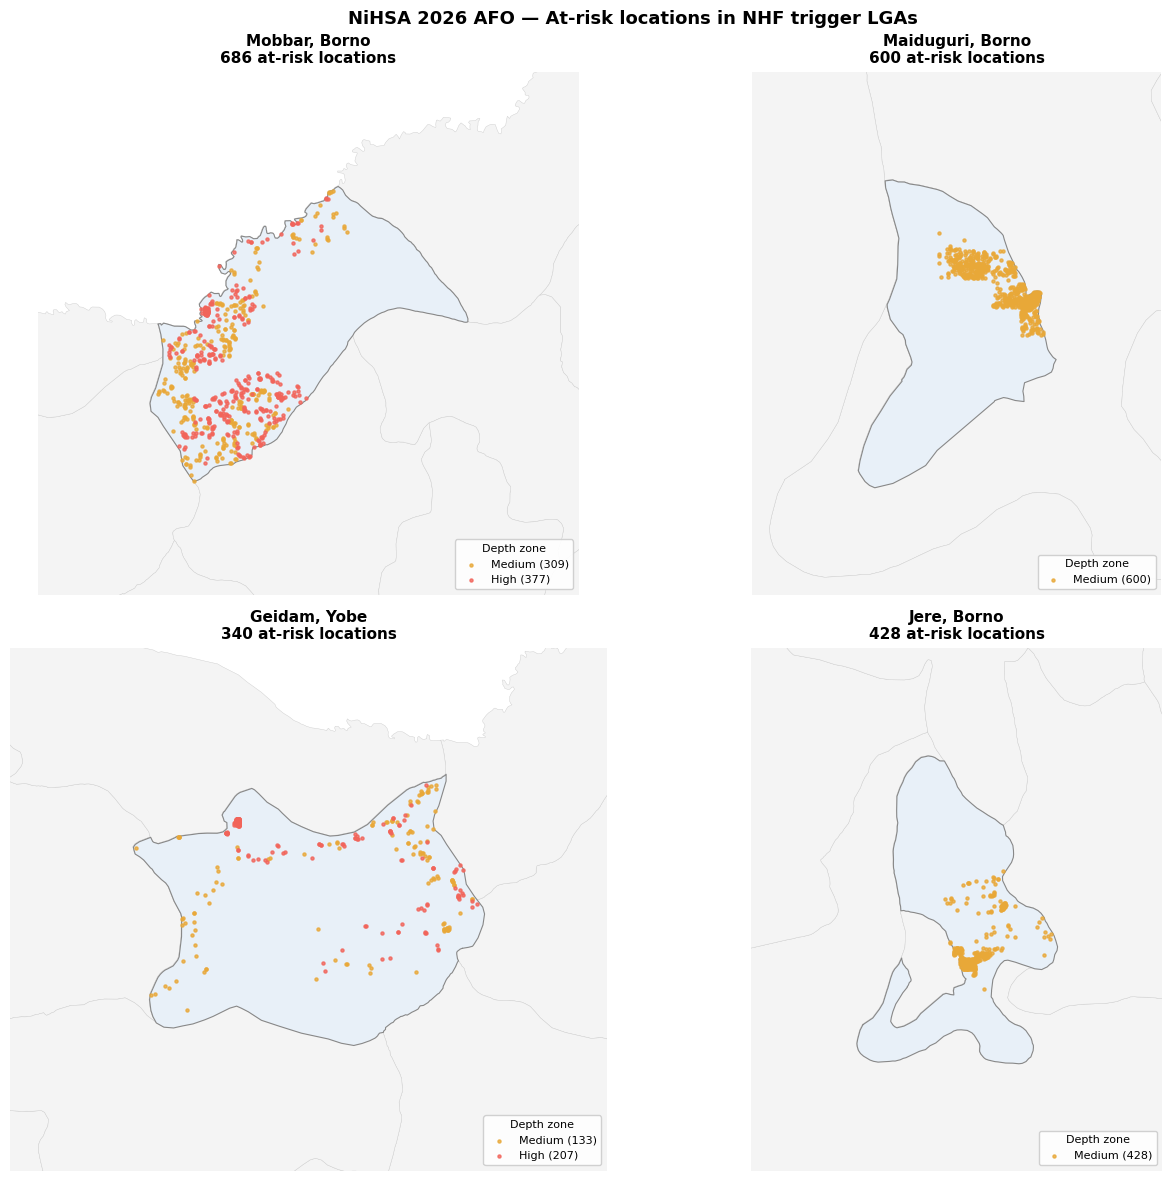

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (pcode, lga_name) in enumerate(NHF_2026.items()):
    ax = axes[i]

    gdf_lga_sel = gdf_lga[gdf_lga["ADM2_PCODE"] == pcode]
    gdf_com     = gdf_risk_bay[gdf_risk_bay["ADM2_PCODE"] == pcode].copy()

    # Neighbouring LGAs for context
    bounds = gdf_lga_sel.total_bounds
    pad    = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 0.35
    gdf_ctx = gdf_lga.cx[
        bounds[0] - pad : bounds[2] + pad,
        bounds[1] - pad : bounds[3] + pad,
    ]

    gdf_ctx.plot(ax=ax, facecolor="#f4f4f4", edgecolor="#cccccc", linewidth=0.3)
    gdf_lga_sel.plot(ax=ax, facecolor="#e8f0f8", edgecolor="#888888", linewidth=0.8)

    for zone in reversed(ZONE_ORDER):
        sub = gdf_com[gdf_com["depth_zone"] == zone]
        if sub.empty:
            continue
        sub.plot(ax=ax, color=ZONE_COLORS[zone], markersize=5, alpha=0.8,
                 zorder=3, label=f"{zone} ({len(sub):,})")

    state = gdf_lga_sel["ADM1_EN"].iloc[0]
    n_total = len(gdf_com)
    ax.set_title(f"{lga_name}, {state}\n{n_total:,} at-risk locations",
                 fontsize=11, fontweight="bold")
    ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    ax.set_ylim(bounds[1] - pad, bounds[3] + pad)
    ax.set_axis_off()
    ax.legend(loc="lower right", fontsize=8, framealpha=0.9,
              title="Depth zone", title_fontsize=8)

fig.suptitle(
    "NiHSA 2026 AFO — At-risk locations in NHF trigger LGAs",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

## 4. Depth Profile — Flood Depth Distribution in Selected LGAs

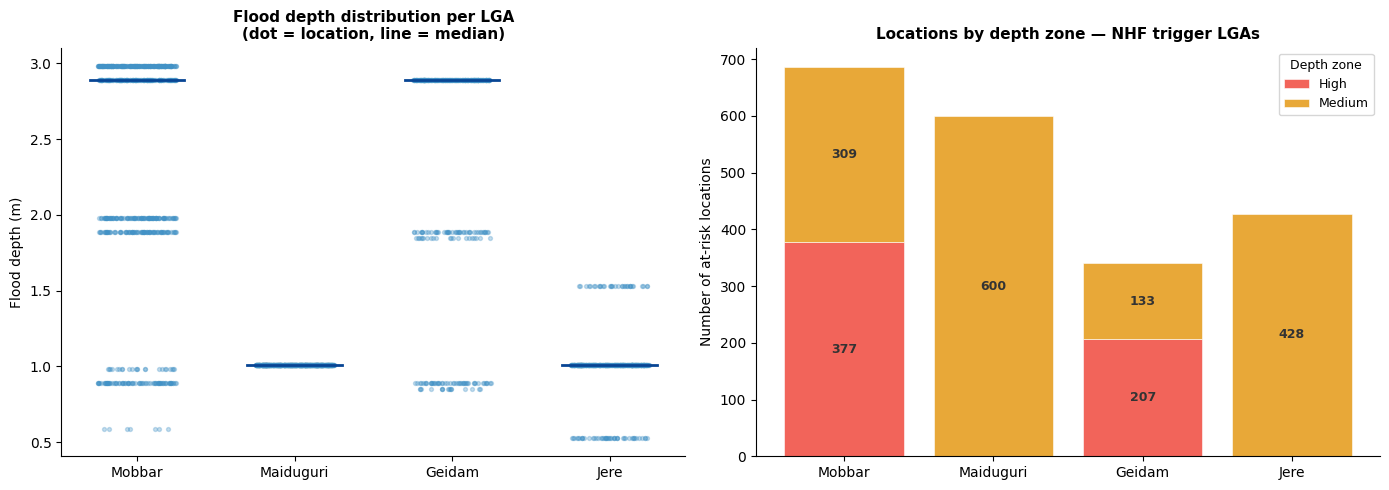

In [11]:
gdf_nhf_com = gdf_risk_bay[gdf_risk_bay["ADM2_PCODE"].isin(NHF_2026.keys())].copy()
gdf_nhf_com["lga_label"] = gdf_nhf_com["ADM2_PCODE"].map(NHF_2026)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: depth distribution (violin / strip) ──────────────────────────────
ax = axes[0]
lga_order = list(NHF_2026.values())
for j, lga in enumerate(lga_order):
    depths = gdf_nhf_com.loc[gdf_nhf_com["lga_label"] == lga, "depth_m"].dropna()
    jitter = np.random.default_rng(42).uniform(-0.25, 0.25, len(depths))
    ax.scatter(np.full(len(depths), j) + jitter, depths,
               alpha=0.3, s=8, color="#4292c6", zorder=2)
    ax.plot([j - 0.3, j + 0.3], [depths.median(), depths.median()],
            color="#084594", linewidth=2, zorder=3)

ax.set_xticks(range(len(lga_order)))
ax.set_xticklabels(lga_order, fontsize=10)
ax.set_ylabel("Flood depth (m)", fontsize=10)
ax.set_title("Flood depth distribution per LGA\n(dot = location, line = median)",
             fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# ── Panel 2: stacked bar — location counts by depth zone ─────────────────────
ax2 = axes[1]
df_zone = (
    gdf_nhf_com.groupby(["lga_label", "depth_zone"])
    .size()
    .unstack(fill_value=0)
    .reindex(lga_order)
)

bottom = np.zeros(len(lga_order))
for zone in ZONE_ORDER:
    if zone in df_zone.columns:
        vals = df_zone[zone].values
        ax2.bar(lga_order, vals, bottom=bottom, color=ZONE_COLORS[zone],
                label=zone, edgecolor="white", linewidth=0.4)
        for k, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0:
                ax2.text(k, b + v / 2, str(v), ha="center", va="center",
                         fontsize=9, fontweight="600", color="#333")
        bottom += vals

ax2.set_ylabel("Number of at-risk locations", fontsize=10)
ax2.set_title("Locations by depth zone — NHF trigger LGAs",
              fontsize=11, fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(title="Depth zone", fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.show()